In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [39]:
PROJECT_DIR = Path("/Users/linda/RiceDatathon_2026_Finance")
PROC_DIR = PROJECT_DIR / "Data" / "Processed"
FIG_DIR  = PROJECT_DIR / "Outputs" / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PROC_DIR / "panel_with_amenity_scores.csv")

print(panel.shape)

(38941, 123)


In [40]:

COLORS = {
    "blue_1": "#7F0D1D",   # deep crimson
    "blue_2": "#A31621",   # dark vivid red
    "blue_3": "#C7362F",   # strong red
    "blue_4": "#E07A73",   # muted light red
    "grid":  "#D9D9D9",
}

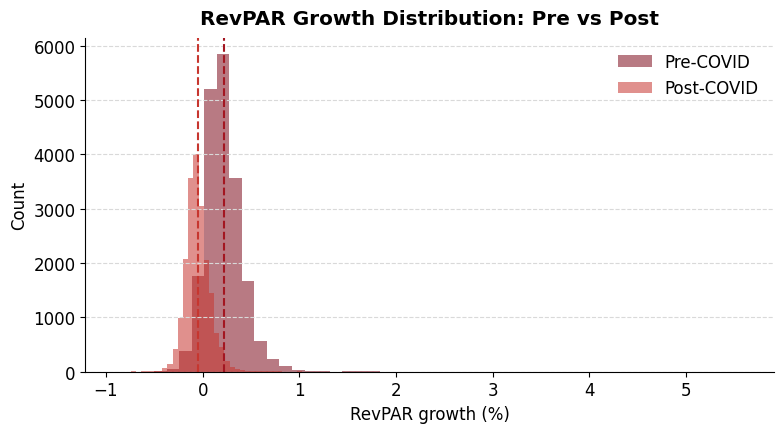

In [41]:
pre  = panel.loc[panel["time_window_tag"]=="pre",  "revpar_growth_2015_2020_pct"].dropna()
post = panel.loc[panel["time_window_tag"]=="post", "revpar_growth_2022_2025_pct"].dropna()

fig, ax = plt.subplots(figsize=(8,4.5))

ax.hist(pre,  bins=50, alpha=0.55, color=COLORS["blue_1"], label="Pre-COVID")
ax.hist(post, bins=50, alpha=0.55, color=COLORS["blue_3"], label="Post-COVID")

ax.axvline(pre.mean(),  color=COLORS["blue_2"], linestyle="--", linewidth=1.5)
ax.axvline(post.mean(), color=COLORS["blue_3"], linestyle="--", linewidth=1.5)

ax.set_title("RevPAR Growth Distribution: Pre vs Post", pad=10)
ax.set_xlabel("RevPAR growth (%)")
ax.set_ylabel("Count")
ax.grid(axis="y", color=COLORS["grid"], linestyle="--", linewidth=0.8)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_revpar_dist_pre_post.png", dpi=200)
plt.show()

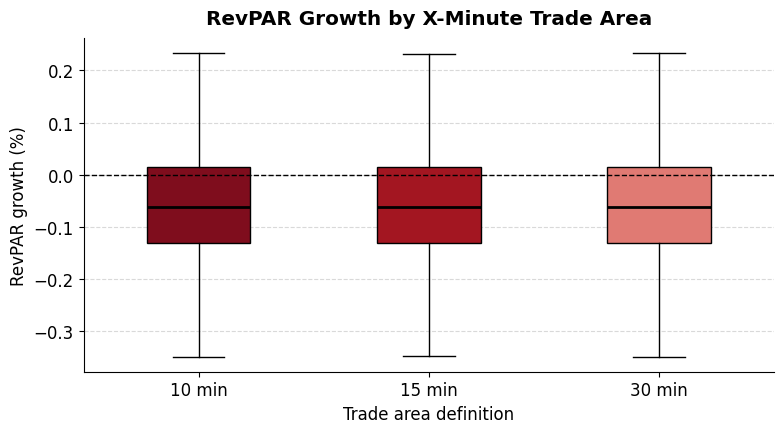

In [42]:
data_10 = panel.loc[panel["drivetime_min"]==10, "revpar_growth_2022_2025_pct"].dropna()
data_15 = panel.loc[panel["drivetime_min"]==15, "revpar_growth_2022_2025_pct"].dropna()
data_30 = panel.loc[panel["drivetime_min"]==30, "revpar_growth_2022_2025_pct"].dropna()

fig, ax = plt.subplots(figsize=(8,4.5))

bp = ax.boxplot(
    [data_10, data_15, data_30],
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)

for box, c in zip(bp["boxes"], [COLORS["blue_1"], COLORS["blue_2"], COLORS["blue_4"]]):
    box.set(facecolor=c, edgecolor="black", linewidth=1)

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xticklabels(["10 min", "15 min", "30 min"])
ax.set_title("RevPAR Growth by X-Minute Trade Area", pad=10)
ax.set_xlabel("Trade area definition")
ax.set_ylabel("RevPAR growth (%)")

ax.grid(axis="y", color=COLORS["grid"], linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_revpar_by_drivetime.png", dpi=200)
plt.show()

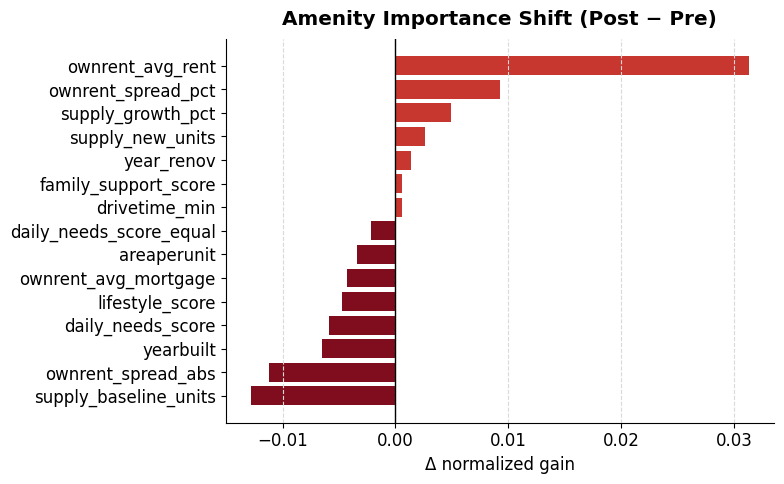

In [43]:
shift = pd.read_csv(PROC_DIR / "importance_shift_post_minus_pre.csv")

top = (
    shift
    .assign(abs_delta=lambda d: d["delta_post_minus_pre"].abs())
    .sort_values("abs_delta", ascending=False)
    .head(15)
    .sort_values("delta_post_minus_pre")
)

fig, ax = plt.subplots(figsize=(8,5))

colors = [
    COLORS["blue_3"] if v > 0 else COLORS["blue_1"]
    for v in top["delta_post_minus_pre"]
]

ax.barh(
    top["feature"],
    top["delta_post_minus_pre"],
    color=colors
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title("Amenity Importance Shift (Post − Pre)", pad=10)
ax.set_xlabel("Δ normalized gain")

ax.grid(axis="x", color=COLORS["grid"], linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_importance_shift_post_minus_pre.png", dpi=200)
plt.show()